# **Day 45: Interpretability II - SHAP and LIME**
*Module 7 - Model Selection, Tuning and Explainability*

Yesterday's tools were **global** (average behaviour). Today we explain **individual predictions**: "Why did the model predict a high landslide susceptibility for **this** slope?" and build global views from many local explanations.

**SHAP** (SHapley Additive exPlanations, Lundberg & Lee, 2017) is the most used explanation method in science today, including remote sensing. **LIME** (Ribeiro et al., 2016) fits a simple local surrogate.

> SHAP splits each individual prediction into contributions from each feature, so we see why this sample got this prediction. LIME explains one prediction with a simple local model.
>
> *Example:* For one pixel predicted as "mining", SHAP might show +0.4 from high SWIR, +0.2 from low NDVI and -0.1 from its elevation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools, math
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestRegressor
import xgboost as xgb
rng = np.random.default_rng(45)
print("shap", shap.__version__)

shap 0.52.0


## **1. Shapley Values**
A prediction is a "payout" shared among features (the "players"). The Shapley value of feature $j$ is its **average marginal contribution** over all orders in which features could be added:
$$\phi_j = \sum_{S\subseteq F\setminus\{j\}}\frac{|S|!\,(|F|-|S|-1)!}{|F|!}\Big[v(S\cup\{j\}) - v(S)\Big]$$
Unique properties: **efficiency** ($\sum_j\phi_j = f(x) - \mathbb E[f(X)]$), symmetry, dummy (no effect -> 0), additivity.

$v(S)$ = expected prediction when only the features in $S$ are known: $\mathbb E[f(x_S, X_{\bar S})]$, estimated by replacing the other features with values from a **background** dataset.

In [2]:
n = 2000
X = pd.DataFrame({"slope": rng.uniform(0, 50, n), "rain_mm": rng.uniform(800, 3500, n), "dist_road_m": rng.exponential(500, n),
                  "ndvi": rng.uniform(0.05, 0.9, n), "lith_soft": rng.integers(0, 2, n)})
logit = (-7 + 0.12 * X.slope + 0.0012 * X.rain_mm - 0.002 * X.dist_road_m - 2.0 * X.ndvi + 1.2 * X.lith_soft
         + 0.03 * X.slope * X.lith_soft)
y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
model = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, enable_categorical=False, random_state=0).fit(X_tr, y_tr)
print("landslide rate", y.mean().round(3), "| test accuracy", round(model.score(X_te, y_te), 3))

def f_logodds(Z):                                       # explain the model's log-odds output
    return model.predict(Z, output_margin=True)

def exact_shapley(f, x, background):
    feats = list(x.index); M = len(feats); phi = np.zeros(M)
    def v(S):
        Z = background.copy()
        for c in S: Z[c] = x[c]
        return f(Z).mean()
    cache = {}
    for j, fj in enumerate(feats):
        others = [c for c in feats if c != fj]
        for size in range(M):
            for S in itertools.combinations(others, size):
                w = math.factorial(size) * math.factorial(M - size - 1) / math.factorial(M)
                key_with, key_without = frozenset(S + (fj,)), frozenset(S)
                if key_with not in cache: cache[key_with] = v(list(key_with))
                if key_without not in cache: cache[key_without] = v(list(key_without))
                phi[j] += w * (cache[key_with] - cache[key_without])
    return pd.Series(phi, index=feats), v([])

background = X_tr.sample(100, random_state=0)            # shap uses at most 100 background rows by default
x0 = X_te.iloc[0]
phi_exact, base = exact_shapley(f_logodds, x0, background)
print("instance:", x0.round(2).to_dict())
print("exact Shapley values (log-odds):", phi_exact.round(4).to_dict())
print(f"efficiency check: base {base:.4f} + sum(phi) {phi_exact.sum():.4f} = {base + phi_exact.sum():.4f} | f(x) = {f_logodds(x0.to_frame().T)[0]:.4f}")

landslide rate 0.234 | test accuracy 0.865
instance: {'slope': 23.29, 'rain_mm': 3333.43, 'dist_road_m': 84.47, 'ndvi': 0.76, 'lith_soft': 1.0}
exact Shapley values (log-odds): {'slope': 0.0492, 'rain_mm': 1.8471, 'dist_road_m': 0.9149, 'ndvi': -0.886, 'lith_soft': 0.6919}
efficiency check: base -2.7002 + sum(phi) 2.6170 = -0.0832 | f(x) = -0.0832


Exact computation needs $2^M$ coalitions: impossible beyond ~15 features. The `shap` library uses model structure (trees, linear models, deep nets) or sampling to compute them efficiently.

## **2. TreeExplainer: Exact and Fast for Tree Ensembles**

In [3]:
explainer_interv = shap.TreeExplainer(model, data=background, feature_perturbation="interventional", model_output="raw")
sv_one = explainer_interv(x0.to_frame().T)
print("shap TreeExplainer (interventional):", dict(zip(X.columns, sv_one.values[0].round(4).tolist())))
print("max difference from our exact computation:", np.abs(sv_one.values[0] - phi_exact.values).max().round(6))

shap TreeExplainer (interventional): {'slope': 0.0492, 'rain_mm': 1.8471, 'dist_road_m': 0.9149, 'ndvi': -0.886, 'lith_soft': 0.6919}
max difference from our exact computation: 0.0


## **3. Local Explanation Plots**

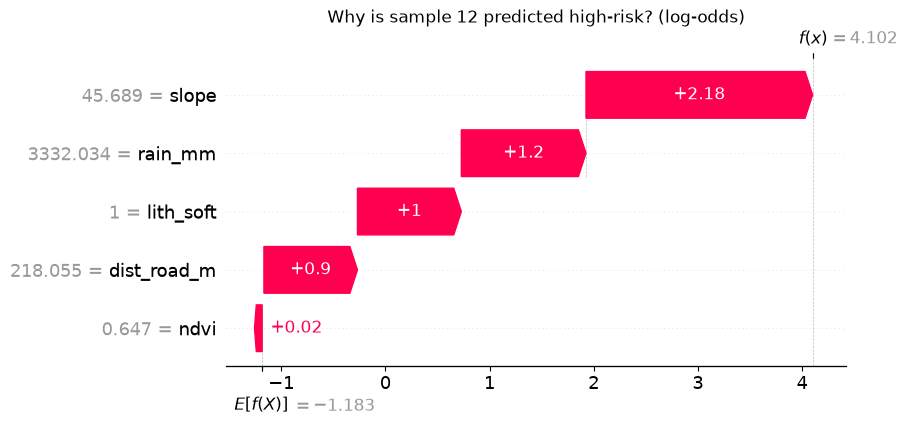

In [4]:
explainer = shap.TreeExplainer(model)                       # path-dependent version, no background needed (fast)
sv = explainer(X_te)
high = int(np.argmax(model.predict_proba(X_te)[:, 1]))
shap.plots.waterfall(sv[high], show=False); plt.title(f"Why is sample {high} predicted high-risk? (log-odds)"); plt.show()

The waterfall starts at the **base value** (average log-odds) and adds each feature's contribution to reach this sample's prediction.

## **4. Global Explanations From Local Ones**

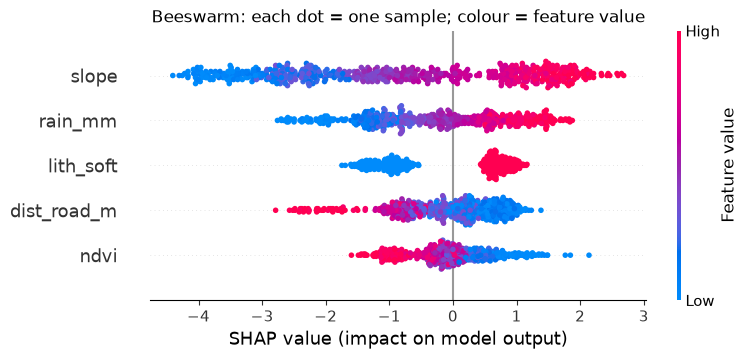

In [5]:
shap.plots.beeswarm(sv, show=False); plt.title("Beeswarm: each dot = one sample; colour = feature value"); plt.show()

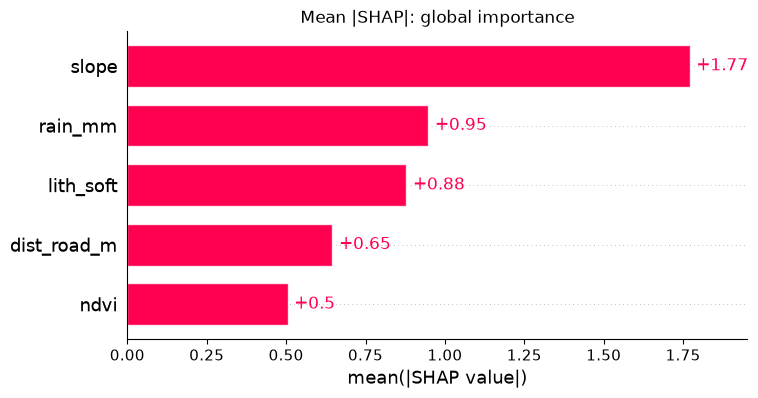

In [6]:
shap.plots.bar(sv, show=False); plt.title("Mean |SHAP|: global importance"); plt.show()

### Dependence plots: effect shape and interactions

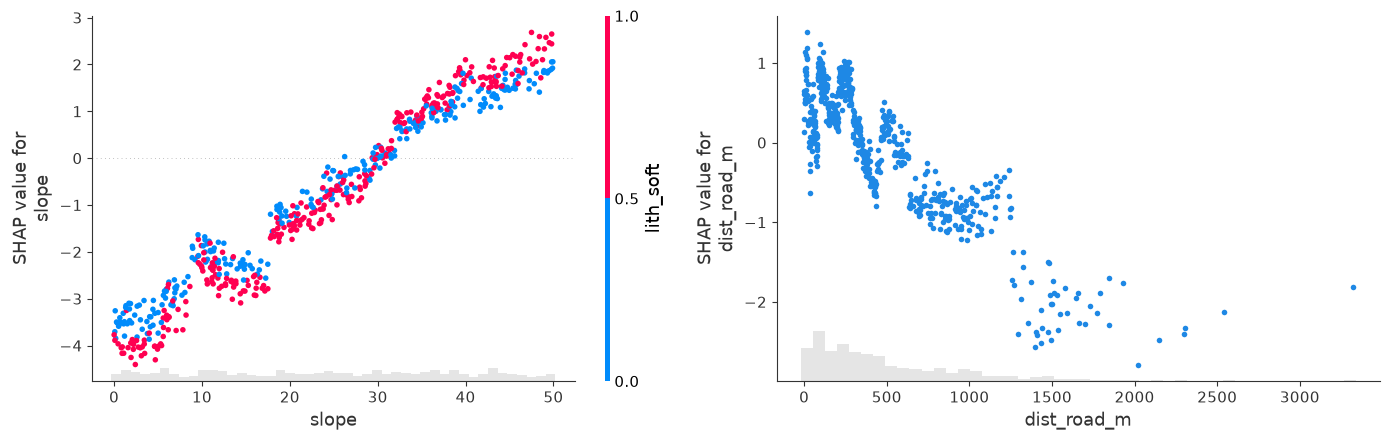

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
shap.plots.scatter(sv[:, "slope"], color=sv[:, "lith_soft"], ax=axes[0], show=False)
shap.plots.scatter(sv[:, "dist_road_m"], ax=axes[1], show=False)
plt.tight_layout(); plt.show()

The slope effect is steeper on soft lithology (the colour split): the model learned the simulated interaction.

### SHAP interaction values
For trees, SHAP can split each prediction into main effects and pairwise interactions.

strongest pairwise interaction: ('slope', 'lith_soft') 0.1716


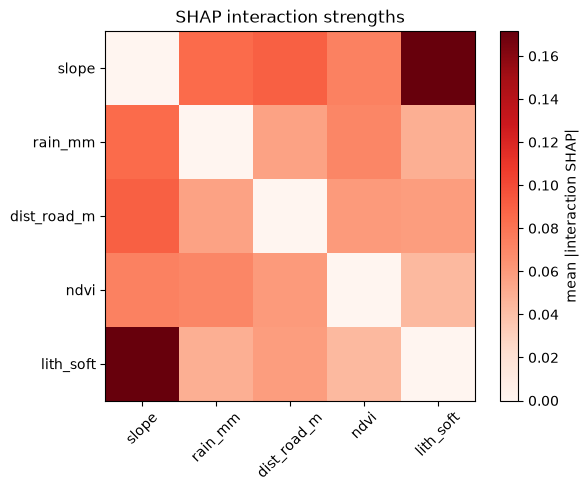

In [8]:
inter = explainer.shap_interaction_values(X_te.iloc[:500])
mean_abs_inter = np.abs(inter).mean(0)
inter_df = pd.DataFrame(mean_abs_inter, index=X.columns, columns=X.columns)
off = inter_df.where(~np.eye(len(X.columns), dtype=bool))
print("strongest pairwise interaction:", off.stack().idxmax(), round(off.stack().max(), 4))
plt.imshow(off.fillna(0), cmap="Reds"); plt.xticks(range(5), X.columns, rotation=45); plt.yticks(range(5), X.columns)
plt.colorbar(label="mean |interaction SHAP|"); plt.title("SHAP interaction strengths"); plt.show()

## **5. Model-Agnostic SHAP (KernelExplainer)**
For any model (SVM, kNN, neural net), KernelSHAP estimates Shapley values with a weighted linear regression on sampled coalitions. Slow, so use a small background summary (k-means).

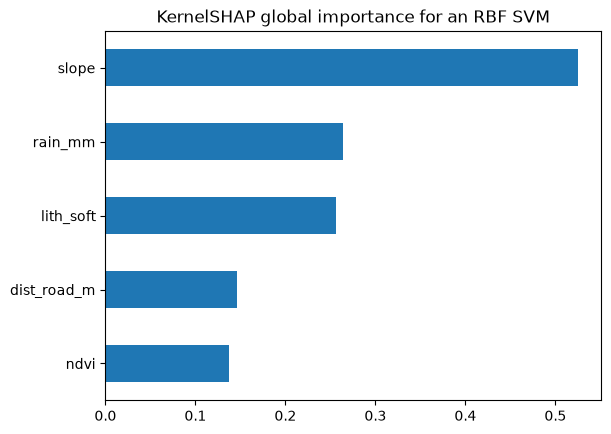

In [9]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
svm = make_pipeline(StandardScaler(), SVC(C=1.0)).fit(X_tr, y_tr)
svm_score = lambda Z: svm.decision_function(pd.DataFrame(Z, columns=X.columns))     # plain function of a NumPy array
kexp = shap.KernelExplainer(svm_score, shap.kmeans(X_tr.values, 20))
sv_svm = kexp.shap_values(X_te.iloc[:40].values, nsamples=300, silent=True)
pd.Series(np.abs(sv_svm).mean(0), index=X.columns).sort_values().plot.barh(title="KernelSHAP global importance for an RBF SVM"); plt.show()

## **6. LIME From Scratch**
LIME explains one prediction by sampling perturbed points **around it**, weighting them by proximity, and fitting a sparse linear model. Its coefficients are the local explanation.

In [10]:
from sklearn.linear_model import Ridge
def lime_explain(predict_fn, x, X_ref, n_samples=3000, kernel_width=0.75, seed=0):
    r = np.random.default_rng(seed)
    mu, sd = X_ref.mean().values, X_ref.std().values
    Z = x.values + r.normal(0, 1, (n_samples, len(x))) * sd * 0.5        # perturb around x
    Zs = (Z - mu) / sd; xs = (x.values - mu) / sd
    d = np.sqrt(((Zs - xs) ** 2).sum(1)) / np.sqrt(len(x))
    w = np.exp(-d ** 2 / kernel_width ** 2)                               # proximity kernel
    target = predict_fn(pd.DataFrame(Z, columns=x.index))
    lin = Ridge(alpha=1.0).fit(Zs, target, sample_weight=w)
    return pd.Series(lin.coef_, index=x.index)                            # effect of +1 SD of each feature, locally

x_hi = X_te.iloc[high]
lime_coef = lime_explain(f_logodds, x_hi, X_tr)
shap_hi = pd.Series(sv.values[high], index=X.columns)
print(pd.DataFrame({"LIME local slope (per +1 SD)": lime_coef.round(3), "SHAP contribution": shap_hi.round(3)}))

             LIME local slope (per +1 SD)  SHAP contribution
slope                               1.074              2.176
rain_mm                             0.439              1.197
dist_road_m                        -0.880              0.898
ndvi                               -0.746              0.017
lith_soft                           2.067              0.997


LIME and SHAP answer **different** questions: LIME gives a local **slope** (what happens if I change the feature a little); SHAP gives an **attribution** of the prediction relative to the baseline. LIME's result depends on the kernel width and sampling (it can be unstable); SHAP has stronger guarantees. The `lime` package (`pip install lime`) provides a polished implementation for tabular, text and image data.

# **Part 2: Going Deeper - SHAP With Correlated Features and Best Practice**

**Interventional** SHAP (marginal background, what we computed) breaks feature correlations, like PDPs: it explains the **model**. **Observational** (conditional) SHAP keeps correlations and spreads credit among correlated features: it explains the **data**. With correlated features, the two can disagree a lot (Janzing et al., 2020; Chen et al., 2020).

In [11]:
Xc = pd.DataFrame({"a": rng.normal(size=3000)}); Xc["b"] = Xc.a + rng.normal(0, 0.1, 3000); Xc["c"] = rng.normal(size=3000)
yc = 3 * Xc.a + Xc.c + rng.normal(0, 0.3, 3000)                    # only 'a' (not 'b') truly matters
rf = RandomForestRegressor(200, max_features=1, random_state=0, n_jobs=-1).fit(Xc, yc)    # max_features=1 forces use of 'b' too
sv_c = shap.TreeExplainer(rf, data=Xc.sample(100, random_state=0), feature_perturbation="interventional")(Xc.iloc[:200])
print("mean |SHAP| (interventional):", dict(zip(Xc.columns, np.abs(sv_c.values).mean(0).round(3).tolist())))
print("The model splits credit between a and its near-copy b: SHAP faithfully reports what the MODEL uses, not the true cause.")

mean |SHAP| (interventional): {'a': 1.33, 'b': 1.118, 'c': 0.751}
The model splits credit between a and its near-copy b: SHAP faithfully reports what the MODEL uses, not the true cause.


### Checklist for using SHAP in a paper
1. Explain a **validated** model; state the test performance.
2. Compute SHAP on **held-out** data; state the explainer, background data and output scale (log-odds or probability).
3. Report global (beeswarm/bar) **and** dependence plots for key drivers; discuss physical plausibility.
4. Discuss **correlated features** (group them or use conditional approaches).
5. Do not claim **causality**; SHAP explains associations learned by the model.
6. Check robustness: SHAP rankings across CV folds / random seeds.

## **Practice Problems**
1. Use `shap.plots.waterfall` for the sample with the **lowest** predicted risk. Which features push it down?
2. Compute mean |SHAP| for each CV fold model (5 folds) and plot the rank stability of features.
3. Change LIME's `kernel_width` to 0.2 and 3.0. How do the explanations change?
4. *(Advanced)* Verify the **efficiency property** for all test samples using `sv.base_values + sv.values.sum(1)` vs `model.predict(X_te, output_margin=True)`.

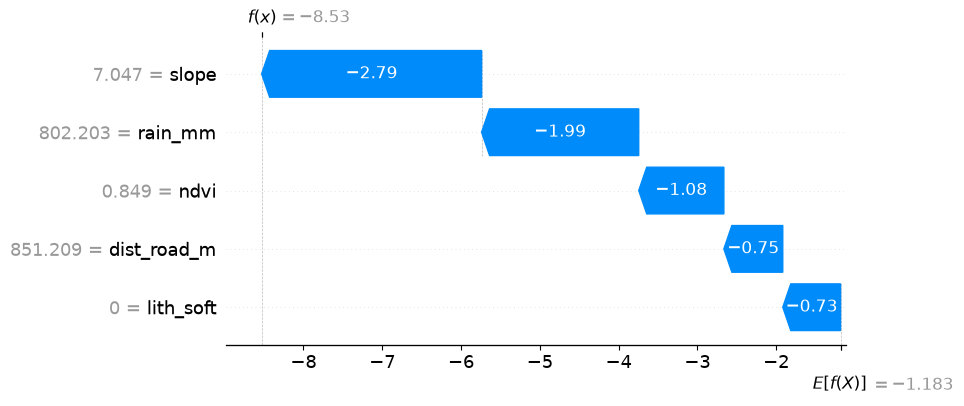

             fold0  fold1  fold2  fold3  fold4
slope          1.0    1.0    1.0    1.0    1.0
rain_mm        3.0    3.0    3.0    2.0    3.0
dist_road_m    4.0    4.0    5.0    4.0    4.0
ndvi           5.0    5.0    4.0    5.0    5.0
lith_soft      2.0    2.0    2.0    3.0    2.0
kernel width 0.2: {'slope': 1.108, 'rain_mm': 0.62, 'dist_road_m': -1.162, 'ndvi': -0.638, 'lith_soft': 3.373}
kernel width 3.0: {'slope': 1.091, 'rain_mm': 0.444, 'dist_road_m': -0.837, 'ndvi': -0.733, 'lith_soft': 1.898}
efficiency holds for all samples: True


In [12]:
# Solution 1
low = int(np.argmin(model.predict_proba(X_te)[:, 1])); shap.plots.waterfall(sv[low], show=False); plt.show()
# Solution 2
from sklearn.model_selection import StratifiedKFold
ranks = []
for tr, te in StratifiedKFold(5, shuffle=True, random_state=0).split(X, y):
    m = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, enable_categorical=False, random_state=0).fit(X.iloc[tr], y[tr])
    ranks.append(pd.Series(np.abs(shap.TreeExplainer(m)(X.iloc[te]).values).mean(0), index=X.columns).rank(ascending=False))
print(pd.DataFrame(ranks).T.rename(columns=lambda i: f"fold{i}"))
# Solution 3
for kw in [0.2, 3.0]:
    print(f"kernel width {kw}:", lime_explain(f_logodds, x_hi, X_tr, kernel_width=kw).round(3).to_dict())
# Solution 4
print("efficiency holds for all samples:", np.allclose(sv.base_values + sv.values.sum(1), model.predict(X_te, output_margin=True), atol=1e-4))

## **Key References**
- Shapley, L. S. (1953). A value for n-person games. *Contributions to the Theory of Games*, 2(28), 307-317.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 30*.
- Lundberg, S. M. et al. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, 2(1), 56-67.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. *KDD 2016*.
- Janzing, D., Minorics, L., & Blobaum, P. (2020). Feature relevance quantification in explainable AI: A causal problem. *AISTATS 2020*.
- Molnar, C. et al. (2022). General pitfalls of model-agnostic interpretation methods for machine learning models. *xxAI - Beyond Explainable AI*, LNCS 13200, 39-68.